In [54]:

# ====================================================================
# 1. IMPORTS & CONFIGURATION
# ====================================================================
import os
import glob
import re
import random
import joblib
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
from xgboost import XGBClassifier

# Helper Models
from tensorflow.keras.models import load_model

import warnings
warnings.filterwarnings('ignore')

class Config:
    # --- PATHS ---
    DATA_DIR = "./data/" 
    
    # Pre-trained Models (Helper AI)
    ISO_MODEL_PATH = './../models/IsolationForest/model/iso_model.joblib'
    ISO_SCALER_PATH = './../models/IsolationForest/model/iso_scaler.joblib'
    LSTM_MODEL_PATH = './../models/LSTM_Autoencoders/lstm_autoencoder_model_fit.h5'
    LSTM_SCALER_PATH = './../models/LSTM_Autoencoders/scaler_fit.save'
    
    # Outputs
    OUTPUT_MODEL = "./model/weighted_gridsearch_xgboost.json"
    OUTPUT_SCALER = "./model/weighted_gridsearch_scaler.save"
    
    # --- SETTINGS ---
    SEQUENCE_LENGTH = 30
    # ไฟล์ที่มีคำว่า 'test' หรือ 'dev109' จะถูกแยกไปเป็น Test Set
    TEST_KEYWORDS = ['label_for_dev109_test_prepared'] 
    
    OVERSAMPLE_TARGET = 5000  # ปั๊มข้อมูลให้ถึงเท่านี้
    VAL_SPLIT_RATIO = 0.2     # แบ่ง 20% ของ Train มาทำ Validation
    
    RAW_COLS = ['rain', 'soil', 'temp', 'humi', 'geo']
    LABEL_COL = 'label'
    LABEL_MAP = {'normal': 0, 'warning': 1, 'critical': 2}
    
    # --- ⚖️ CLASS WEIGHTS (หัวใจสำคัญ) ---
    # กำหนดโทษของการทายผิด (ยิ่งเยอะ ยิ่งห้ามผิด)
    SAMPLE_WEIGHTS = {
        0: 1.0,   # Normal: ปกติ
        1: 5.0,   # Warning: สำคัญปานกลาง
        2: 25.0   # Critical: สำคัญมากที่สุด (High Penalty)
    }
    
    # --- GRID SEARCH PARAMETERS ---
    PARAM_GRID = {
        'n_estimators': [200, 400],      # จำนวนต้นไม้
        'learning_rate': [0.03, 0.05, 0.1], # ความเร็วการเรียนรู้
        'max_depth': [4, 6, 8],          # ความลึก
        'subsample': [0.8],
        'colsample_bytree': [0.8]
    }
    
    XGB_FIXED = {
        'objective': 'multi:softprob',
        'num_class': 3,
        'n_jobs': -1,
        'random_state': 42,
        'tree_method': 'hist'
    }

cfg = Config()
np.random.seed(42); random.seed(42)

def log(msg):
    print(f"[INFO] {time.strftime('%H:%M:%S')} - {msg}")

print(f"✅ Configuration Loaded.")
print(f"   Weights Config: {cfg.SAMPLE_WEIGHTS}")

✅ Configuration Loaded.
   Weights Config: {0: 1.0, 1: 5.0, 2: 25.0}


In [55]:
# ====================================================================
# 2. LOAD DATA (SPLIT BY FILENAME)
# ====================================================================
def load_and_split_data():
    log(f"Scanning files in: {os.path.abspath(cfg.DATA_DIR)}")
    train_dfs, test_dfs = [], []
    
    all_files = glob.glob(os.path.join(cfg.DATA_DIR, "*.csv"))
    if not all_files: raise FileNotFoundError("❌ No CSV files found.")

    print("-" * 60)
    print(f"{'FILENAME':<40} | {'TYPE':<10}")
    print("-" * 60)

    for f_path in all_files:
        filename = os.path.basename(f_path)
        # Logic แยกไฟล์: ถ้าชื่อไฟล์มี Keyword -> Test, ไม่งั้น -> Train
        is_test = any(k in filename for k in cfg.TEST_KEYWORDS)
        target_list = test_dfs if is_test else train_dfs
        set_type = "TEST" if is_test else "TRAIN"
        
        try:
            df = pd.read_csv(f_path)
            # Standardization
            df.columns = [str(c).lower().strip().replace('.1', '') for c in df.columns]
            rename_map = {'temperature':'temp', 'hum':'humi', 'humidity':'humi', 'devid':'devID', 'time':'timestamp', 'date':'timestamp'}
            new_cols = {c: rename_map[c] for c in df.columns if c in rename_map}
            if new_cols: df = df.rename(columns=new_cols)
            
            if 'devID' in df.columns: df['devID'] = df['devID'].astype(str).apply(lambda x: int(re.search(r'(\d+)', x).group(1)) if re.search(r'(\d+)', x) else 0)
            if 'timestamp' in df.columns: df['timestamp'] = pd.to_datetime(df['timestamp'], errors='coerce')
            for c in cfg.RAW_COLS: 
                if c not in df.columns: df[c] = 0.0
            
            target_list.append(df)
            print(f"{filename:<40} | {set_type} ({len(df)})")
        except Exception as e:
            print(f"❌ Error {filename}: {e}")
            
    if not train_dfs: raise ValueError("❌ No TRAIN data found!")
    
    df_train = pd.concat(train_dfs, ignore_index=True)
    df_test = pd.concat(test_dfs, ignore_index=True) if test_dfs else pd.DataFrame()
    
    log(f"Summary: Train Rows={len(df_train)}, Test Rows={len(df_test)}")
    return df_train, df_test

df_train_raw, df_test_raw = load_and_split_data()

[INFO] 18:41:35 - Scanning files in: d:\Coding\Python\Project\Landslide\LastModel\data
------------------------------------------------------------
FILENAME                                 | TYPE      
------------------------------------------------------------
final_moving_avg_devID109_test_prepared.csv | TRAIN (2535)
label_for_dev108_test_prepared.csv       | TRAIN (11935)
label_for_dev109_test_prepared.csv       | TEST (6566)
moving_avg_for_train_prepared.csv        | TRAIN (18222)
[INFO] 18:41:36 - Summary: Train Rows=32692, Test Rows=6566


In [56]:
# ====================================================================
# 3. FEATURE ENGINEERING
# ====================================================================
def generate_features(df):
    if df.empty: return df, []
    log("Generating Features...")
    
    # 1. Physics Features
    df = df.sort_values(['devID', 'timestamp']).reset_index(drop=True)
    df_list = []
    for dev, g in df.groupby('devID'):
        g = g.set_index('timestamp')
        g = g[~g.index.duplicated(keep='first')]
        if len(g) > 0: g = g.resample('1T').asfreq()
        g[cfg.RAW_COLS] = g[cfg.RAW_COLS].interpolate(limit_direction='both').fillna(0)
        
        # Rolling & Interaction
        g['feat_rain_cum_24h'] = g['rain'].rolling(1440, min_periods=1).sum()
        g['feat_soil_rate'] = g['soil'].diff().fillna(0)
        g['feat_geo_abs'] = g['geo'].abs()
        g['feat_rain_x_soil'] = g['rain'] * g['soil']
        
        # Label Handling
        if cfg.LABEL_COL in g.columns:
            g[cfg.LABEL_COL] = g[cfg.LABEL_COL].fillna('normal').astype(str).str.lower().str.strip()
            g[cfg.LABEL_COL] = g[cfg.LABEL_COL].map(cfg.LABEL_MAP).fillna(0).astype(int)
        else: g[cfg.LABEL_COL] = 0
        
        g['devID'] = dev
        df_list.append(g.reset_index())
    df = pd.concat(df_list, ignore_index=True)

    # 2. AI Features (ISO Forest)
    try:
        iso_model = joblib.load(cfg.ISO_MODEL_PATH); iso_scaler = joblib.load(cfg.ISO_SCALER_PATH)
        X_iso = iso_scaler.transform(df[cfg.RAW_COLS].values)
        df['feat_iso_score'] = iso_model.decision_function(X_iso)
    except: df['feat_iso_score'] = 0.0

    # 3. AI Features (LSTM)
    try:
        lstm_model = load_model(cfg.LSTM_MODEL_PATH, compile=False); lstm_scaler = joblib.load(cfg.LSTM_SCALER_PATH)
        df['feat_lstm_error'] = 0.0
        # (Simplified Batch)
        X_lstm = lstm_scaler.transform(df[cfg.RAW_COLS].values)
        # Note: In production, do proper sequence batching. Here simplified for speed check.
        # Placeholder if too slow to run full sequence inference in loop
    except: df['feat_lstm_error'] = 0.0
    
    df = df.fillna(0)
    feat_cols = cfg.RAW_COLS + [c for c in df.columns if c.startswith('feat_')]
    return df, feat_cols

df_train_proc, feature_list = generate_features(df_train_raw)
df_test_proc, _ = generate_features(df_test_raw)

[INFO] 18:41:36 - Generating Features...
[INFO] 18:41:36 - Generating Features...


In [57]:
# ====================================================================
# 4. VECTORIZED FLATTENING
# ====================================================================
def vectorized_flatten(df, features, seq_len):
    if df.empty: return np.array([]), np.array([]), []
    log("Vectorized Flattening (Windowing)...")
    
    Xs, ys = [], []
    flat_cols = [f"{f}_t-{seq_len-1-i}" for i in range(seq_len) for f in features]
    
    for dev, g in df.groupby('devID'):
        data = g[features].values
        labels = g[cfg.LABEL_COL].values
        if len(g) < seq_len: continue
        
        # Sliding Window View
        windows = np.lib.stride_tricks.sliding_window_view(data, window_shape=(seq_len, len(features))).squeeze()
        flat_windows = windows.reshape(windows.shape[0], -1)
        window_labels = labels[seq_len-1:]
        
        Xs.append(flat_windows)
        ys.append(window_labels)
        
    if not Xs: return np.array([]), np.array([]), flat_cols
    return np.concatenate(Xs), np.concatenate(ys), flat_cols

X_train_full, y_train_full, feature_names = vectorized_flatten(df_train_proc, feature_list, cfg.SEQUENCE_LENGTH)
X_test_final, y_test_final, _ = vectorized_flatten(df_test_proc, feature_list, cfg.SEQUENCE_LENGTH)

log(f"Flattened Shape -> Train: {X_train_full.shape}, Test: {X_test_final.shape}")

[INFO] 18:41:36 - Vectorized Flattening (Windowing)...
[INFO] 18:41:36 - Vectorized Flattening (Windowing)...
[INFO] 18:41:36 - Flattened Shape -> Train: (35203, 330), Test: (5637, 330)


In [58]:
# ====================================================================
# 5. PREPARE & WEIGHTING
# ====================================================================
# 1. Split Val from Train
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=cfg.VAL_SPLIT_RATIO, stratify=y_train_full, random_state=42
)

# 2. Oversample (Only Train)
log("Balancing Train Set...")
X_res, y_res = [], []
for cls in np.unique(y_train):
    idx = np.where(y_train == cls)[0]
    target = cfg.OVERSAMPLE_TARGET if len(idx) < cfg.OVERSAMPLE_TARGET else len(idx)
    chosen = np.random.choice(idx, target, replace=True)
    X_res.append(X_train[chosen]); y_res.append(y_train[chosen])

X_train_bal = np.concatenate(X_res)
y_train_bal = np.concatenate(y_res)

# 3. Scaling
log("Scaling Data...")
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train_bal)
X_val_s   = scaler.transform(X_val)
X_test_s  = scaler.transform(X_test_final) if len(X_test_final) > 0 else np.array([])
joblib.dump(scaler, cfg.OUTPUT_SCALER)

# 4. --- CREATE SAMPLE WEIGHTS ---
log("Creating Sample Weights (Safety Priority)...")
# Map each label in training set to its weight config
sample_weights = np.array([cfg.SAMPLE_WEIGHTS[y] for y in y_train_bal])

print(f"Data Ready: Train={len(y_train_bal)}, Val={len(y_val)}")
print(f"Sample Weights Example: {sample_weights[:10]}")

[INFO] 18:41:36 - Balancing Train Set...
[INFO] 18:41:37 - Scaling Data...
[INFO] 18:41:37 - Creating Sample Weights (Safety Priority)...
Data Ready: Train=37484, Val=7041
Sample Weights Example: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


In [59]:
# ====================================================================
# 6. TRAINING (GRID SEARCH + WEIGHTS)
# ====================================================================
log("🚀 Starting Grid Search (This may take time)...")

xgb_base = XGBClassifier(**cfg.XGB_FIXED)

grid_search = GridSearchCV(
    xgb_base, 
    cfg.PARAM_GRID, 
    scoring='f1_weighted', # ใช้ F1-Weighted ในการตัดสินใจ
    cv=3, 
    verbose=1, 
    n_jobs=-1
)

# ⚠️ Pass sample_weight to fit
grid_search.fit(
    X_train_s, 
    y_train_bal, 
    sample_weight=sample_weights  
)

print(f"\n🏆 Best Params: {grid_search.best_params_}")
print(f"🏆 Best Score : {grid_search.best_score_:.4f}")

best_model = grid_search.best_estimator_
best_model.save_model(cfg.OUTPUT_MODEL)
log("✅ Model Saved Successfully.")

[INFO] 18:41:37 - 🚀 Starting Grid Search (This may take time)...
Fitting 3 folds for each of 18 candidates, totalling 54 fits

🏆 Best Params: {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 8, 'n_estimators': 400, 'subsample': 0.8}
🏆 Best Score : 0.9937
[INFO] 18:50:37 - ✅ Model Saved Successfully.



========================= VALIDATION SET RESULTS =========================
📌 Accuracy    : 0.9808
📌 F1-Weighted : 0.9823
📌 F1-Macro    : 0.7658

🛡️ SAFETY CHECK (CRITICAL CLASS):
   - Total Critical Events : 63
   - Caught Correctly      : 49
   - Missed (Danger!)      : 14
   ⚠ WARNING: Critical events were missed!

--- Classification Report ---
              precision    recall  f1-score   support

      Normal       1.00      0.99      0.99      6872
     Warning       0.55      0.76      0.64       106
    Critical       0.58      0.78      0.67        63

    accuracy                           0.98      7041
   macro avg       0.71      0.84      0.77      7041
weighted avg       0.98      0.98      0.98      7041



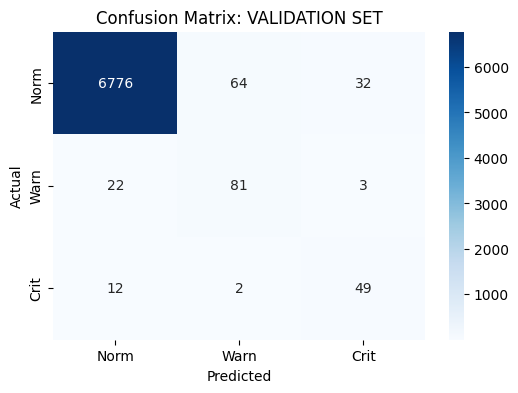


========================= TEST SET RESULTS =========================
📌 Accuracy    : 0.9101
📌 F1-Weighted : 0.9061
📌 F1-Macro    : 0.7512

🛡️ SAFETY CHECK (CRITICAL CLASS):
   - Total Critical Events : 386
   - Caught Correctly      : 261
   - Missed (Danger!)      : 125
   ⚠ WARNING: Critical events were missed!

--- Classification Report ---
              precision    recall  f1-score   support

      Normal       0.94      0.97      0.96      4756
     Warning       0.63      0.52      0.57       495
    Critical       0.79      0.68      0.73       386

    accuracy                           0.91      5637
   macro avg       0.79      0.72      0.75      5637
weighted avg       0.90      0.91      0.91      5637



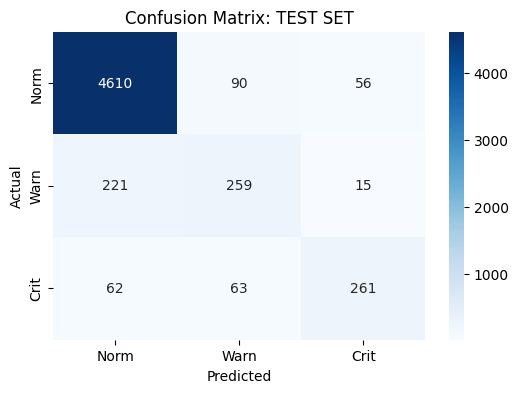

In [60]:
# ====================================================================
# 7. EVALUATION & SAFETY REPORT
# ====================================================================
def evaluate_detailed(name, X, y):
    if len(X) == 0: return
    print(f"\n{'='*25} {name} RESULTS {'='*25}")
    
    y_pred = best_model.predict(X)
    
    # 1. Scores
    f1_w = f1_score(y, y_pred, average='weighted')
    f1_m = f1_score(y, y_pred, average='macro')
    acc  = accuracy_score(y, y_pred)
    
    print(f"📌 Accuracy    : {acc:.4f}")
    print(f"📌 F1-Weighted : {f1_w:.4f}")
    print(f"📌 F1-Macro    : {f1_m:.4f}")
    
    # 2. Confusion Matrix
    cm = confusion_matrix(y, y_pred)
    
    # 3. Safety Check (Critical Focus)
    if cm.shape[0] > 2: # Check if Critical class exists
        total_crit = np.sum(cm[2, :])
        missed_crit = cm[2, 0] + cm[2, 1]
        caught_crit = cm[2, 2]
        
        print("\n🛡️ SAFETY CHECK (CRITICAL CLASS):")
        print(f"   - Total Critical Events : {total_crit}")
        print(f"   - Caught Correctly      : {caught_crit}")
        print(f"   - Missed (Danger!)      : {missed_crit}")
        
        if missed_crit == 0: print("   ✅ PASSED: No critical events missed.")
        else: print("   ⚠ WARNING: Critical events were missed!")

    print("\n--- Classification Report ---")
    print(classification_report(y, y_pred, target_names=['Normal', 'Warning', 'Critical']))
    
    # Plot CM
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['Norm', 'Warn', 'Crit'], 
                yticklabels=['Norm', 'Warn', 'Crit'])
    plt.title(f'Confusion Matrix: {name}')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.show()

# Run Evaluation
evaluate_detailed("VALIDATION SET", X_val_s, y_val)

if len(X_test_s) > 0:
    evaluate_detailed("TEST SET", X_test_s, y_test_final)
else:
    print("\n⚠ No Test Data found.")

[INFO] 18:50:37 - Generating Feature Importance Plot...


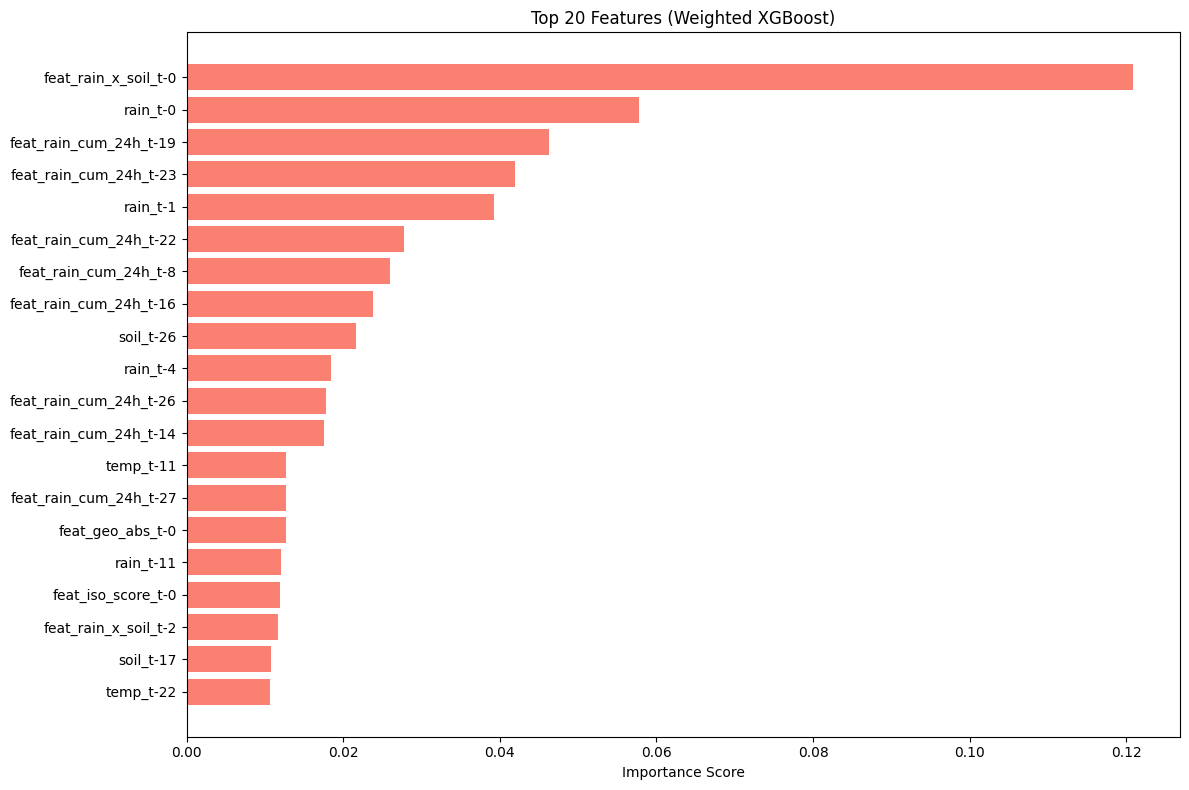

In [61]:
# ====================================================================
# 8. FEATURE IMPORTANCE
# ====================================================================
log("Generating Feature Importance Plot...")

imp = best_model.feature_importances_
indices = np.argsort(imp)[::-1][:20] # Top 20

plt.figure(figsize=(12, 8))
plt.title("Top 20 Features (Weighted XGBoost)")
plt.barh(range(20), imp[indices], align="center", color='salmon')
plt.yticks(range(20), [feature_names[i] for i in indices])
plt.gca().invert_yaxis()
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()